### Look at Seizure Spread Features

#### Load data and add patient and roi level info

In [1]:
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

## load csv
seizure_spread_dynasd_init = pd.read_csv('/users/kgwalsh/projects/2_RNS_biomarkers/modules/biomarker_analysis/derivatives/WO_seizure_spread_wavenet_12825.csv')

Quick check of focality using mean pairwise distance

/tmp/ipykernel_29487/2771933838.py:16: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  seizure_focality = early_spread.groupby(['patient', 'onset', 'outcome']).apply(calculate_focality).reset_index()
/tmp/ipykernel_29487/2771933838.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=pt_focality, x='outcome', y='mean_spread_distance', palette='Set3')


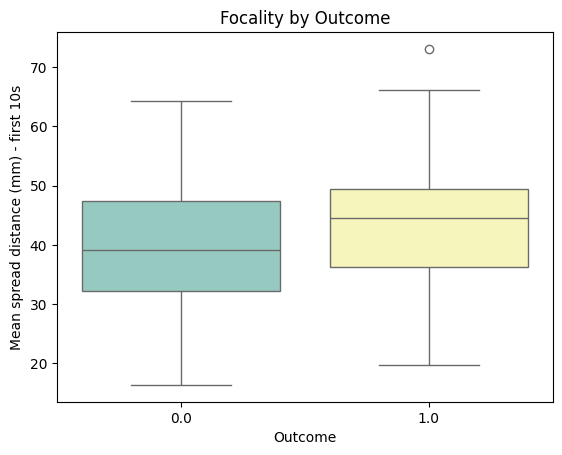

In [2]:
### check focality quickly
from scipy.spatial.distance import pdist

early_spread = seizure_spread_dynasd_init[seizure_spread_dynasd_init['time'] <= 20]

# Ffor each seizure, calculate mean pairwise distance between all active channels in first X seconds
def calculate_focality(group):
    coords = group[['mm_x', 'mm_y', 'mm_z']].values
    if len(coords) < 2:
        return 0

    # calc all pairwise distances
    distances = pdist(coords, metric='euclidean')
    return distances.mean()

seizure_focality = early_spread.groupby(['patient', 'onset', 'outcome']).apply(calculate_focality).reset_index()
seizure_focality.columns = ['patient', 'seizure', 'outcome', 'mean_spread_distance']

pt_focality = seizure_focality.groupby(['patient', 'outcome']).agg({'mean_spread_distance' : 'mean'}).reset_index()

# Plot
sns.boxplot(data=pt_focality, x='outcome', y='mean_spread_distance', palette='Set3')
plt.ylabel('Mean spread distance (mm) - first 10s')
plt.xlabel('Outcome')
plt.title('Focality by Outcome')
plt.show()

Add features to df (laterality, lobe information)

In [3]:
# fix timing if needed (i.e. subtract first time for all times)
seizure_spread_dynasd = seizure_spread_dynasd_init.rename(columns={'time': 'time_orig'})
seizure_spread_dynasd['time'] = seizure_spread_dynasd.groupby(['patient', 'onset'])['time_orig'].transform(lambda x: x - x.min())

# group by engel
seizure_spread_dynasd['engel_group'] = seizure_spread_dynasd['engel'].astype(str).str.split('.').str[0]

# extract rh and lh from roi column
def extract_hemisphere(roi):
    if pd.isna(roi):
        return None
    roi = roi.lower()
    if 'right' in roi or '-rh-' in roi:
        return 'right'
    elif 'left' in roi or '-lh-' in roi:
        return 'left'
    else:
        return 'unknown'

seizure_spread_dynasd['roi_laterality'] = seizure_spread_dynasd['roi'].apply(extract_hemisphere)

# add bilateral implant based on whether left and right are in that patient listed roi_laterality
seizure_spread_dynasd['implant_laterality'] = seizure_spread_dynasd.groupby('onset')['roi_laterality'].transform(lambda x: 
    'bilateral' if set(['left', 'right']).issubset(set(x.dropna())) else 
    ('left' if 'left' in x.values else 
    ('right' if 'right' in x.values else 'unknown')))


# add lobe information based on roi column
mesial_temporal_keys = ['parahippocampal', 'hippocampus', 'amygdala', 'entorhinal']
lateral_temporal_keys = ['temporal', 'fusiform', 'transversetemporal', 'bankssts']
frontal_lobe_keys = ['frontal', 'precentral', 'paracentral','parsopercularis', 'parstriangularis', 'parsorbitalis']
parietal_lobe_keys = ['parietal', 'postcentral', 'supramarginal', 'precuneus']
occipital_lobe_keys = ['occipital', 'cuneus', 'lingual','pericalcarine']
cingulate_lobe_keys = ['cingulate']
subcortical_keys = ['thalamus', 'caudate', 'putamen', 'pallidum', 'accumbens', 'ventraldc', 'brainstem']

# find rois not containing any of the above keys
def extract_lobe(roi):
    if pd.isna(roi):
        return None
    roi = roi.lower()
    if any(key in roi for key in mesial_temporal_keys):
        return 'mesial_temporal'
    elif any(key in roi for key in lateral_temporal_keys):
        return 'lateral_temporal'
    elif any(key in roi for key in frontal_lobe_keys):
        return 'frontal_lobe'
    elif any(key in roi for key in parietal_lobe_keys):
        return 'parietal_lobe'
    elif any(key in roi for key in occipital_lobe_keys):
        return 'occipital_lobe'
    elif any(key in roi for key in cingulate_lobe_keys):
        return 'cingulate_lobe'
    elif 'insula' in roi:
        return 'insula'
    elif any(key in roi for key in subcortical_keys):
        return 'subcortical'
    elif 'white-matter' in roi:
        return 'white-matter'
    else:
        return 'other'
    
seizure_spread_dynasd['roi_lobe'] = seizure_spread_dynasd['roi'].apply(extract_lobe)   

# print distribution of roi_lobe
print(seizure_spread_dynasd['roi_lobe'].value_counts())
other_rois = seizure_spread_dynasd[seizure_spread_dynasd['roi_lobe'] == 'other']['roi'].unique()
print(f"Other ROIs: {other_rois}")

# add bilateral_temporal implant designation
seizure_spread_dynasd['implant_temporal_laterality'] = seizure_spread_dynasd.groupby('onset')['roi_lobe'].transform(
    lambda x: 'bilateral_temporal' if (
        any(lobe in ['mesial_temporal', 'lateral_temporal'] for lobe in x[seizure_spread_dynasd.loc[x.index, 'roi_laterality'] == 'left']) and
        any(lobe in ['mesial_temporal', 'lateral_temporal'] for lobe in x[seizure_spread_dynasd.loc[x.index, 'roi_laterality'] == 'right'])
    ) else 'unilateral_temporal'
)

# add GM WM designation based on roi column
def extract_gm_wm(roi):
    if pd.isna(roi):
        return None
    roi = roi.lower()
    if 'white-matter' in roi or 'wm' in roi:
        return 'WM'
    else:
        return 'GM'

seizure_spread_dynasd['roi_type'] = seizure_spread_dynasd['roi'].apply(extract_gm_wm)

roi_lobe
lateral_temporal    15081
frontal_lobe        12326
parietal_lobe        9929
white-matter         9336
mesial_temporal      5368
insula               1688
cingulate_lobe       1266
occipital_lobe        968
subcortical           871
Name: count, dtype: int64
Other ROIs: []


Text(0.5, 1.0, 'Therapy Type vs Outcome\np=0.1494')

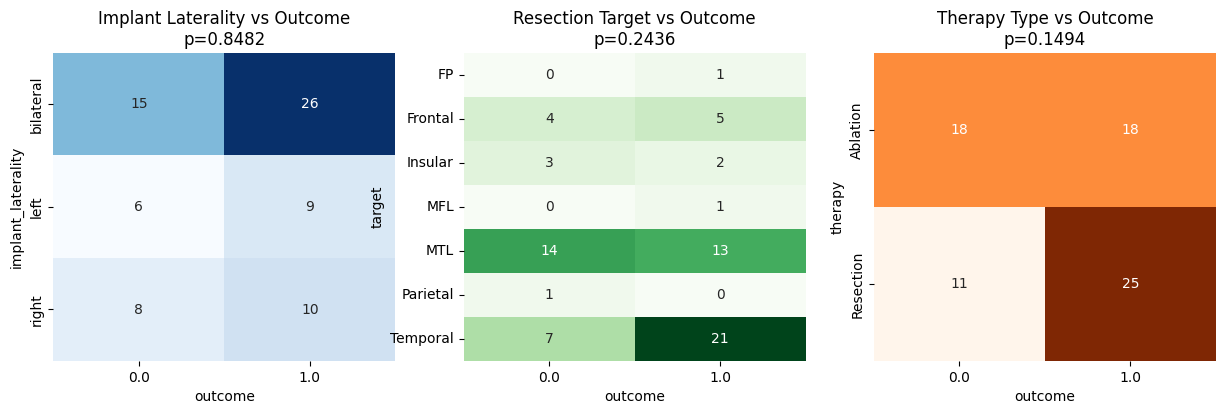

In [4]:
### patient level metadata checks
import pandas as pd
import numpy as np
from scipy.stats import chi2_contingency, fisher_exact
import matplotlib.pyplot as plt
import seaborn as sns

patient_summary = seizure_spread_dynasd[['patient', 'implant_laterality', 'target', 'therapy', 'outcome', 'engel_group']].drop_duplicates().reset_index(drop=True)

# contigency table
table1 = pd.crosstab(patient_summary['implant_laterality'], patient_summary['outcome'])
chi2_1, p1, dof1, exp1 = chi2_contingency(table1)

table2 = pd.crosstab(patient_summary['target'], patient_summary['outcome'])
chi2_2, p2, dof2, exp2 = chi2_contingency(table2)

table3 = pd.crosstab(patient_summary['therapy'], patient_summary['outcome'])
chi2_3, p3, dof3, exp3 = chi2_contingency(table3)

# Create and visualize each table
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Laterality
sns.heatmap(table1, annot=True, cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Implant Laterality vs Outcome\np={p1:.4f}')

# Target
sns.heatmap(table2, annot=True, cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f'Resection Target vs Outcome\np={p2:.4f}')

# Therapy type
sns.heatmap(table3, annot=True, cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title(f'Therapy Type vs Outcome\np={p3:.4f}')

#### Time to Spread Analysis (Andy)

Andy's methods:
- difference then abs value in time between average L and R temporal times
- fill nans with inifiinity
- add 1 to evertyhing, take 1 over that

##### Average time to contralateral spread (seizure level):

/tmp/ipykernel_29487/2512203498.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=seizure_times_wide, x='outcome', y='avg_contra',


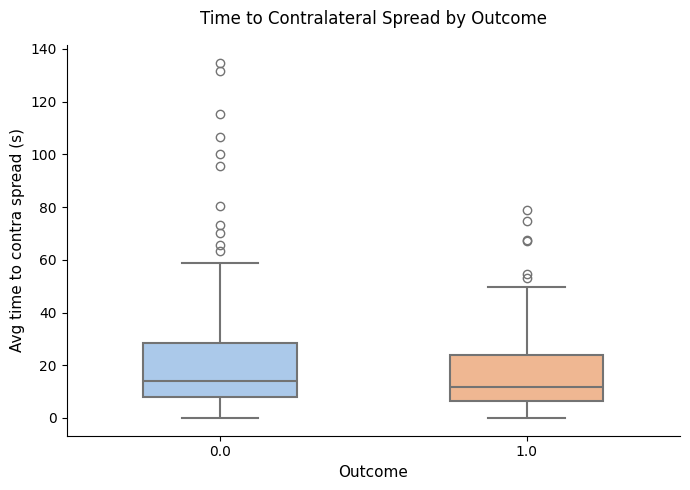

In [5]:
# avg onset onset side of contralateral spread (seizure level)
seizure_spread_dynasd_bilteral = seizure_spread_dynasd[seizure_spread_dynasd['implant_temporal_laterality'] == 'bilateral_temporal']
#seizure_spread_dynasd_bilteral = seizure_spread_dynasd_bilteral.dropna(subset=['time']) # drop nans?

temporal_df = seizure_spread_dynasd_bilteral[
    seizure_spread_dynasd_bilteral['roi_lobe'].isin(['mesial_temporal', 'lateral_temporal'])
]

# avg time per laterality (left vs right temporal)
seizure_laterality_times = temporal_df.groupby(['onset', 'outcome', 'laterality', 'roi_laterality']).agg({
    'time': 'mean'  # avg activation time per side
}).reset_index()

seizure_times_wide = seizure_laterality_times.pivot(
    index=['onset', 'outcome', 'laterality'], 
    columns='roi_laterality', 
    values='time'
).reset_index()

seizure_times_wide['left'] = seizure_times_wide['left'].fillna(np.inf)
seizure_times_wide['right'] = seizure_times_wide['right'].fillna(np.inf)

seizure_times_wide['avg_contra'] = np.maximum(seizure_times_wide['left'], seizure_times_wide['right'])

plt.figure(figsize=(7, 5))
sns.boxplot(data=seizure_times_wide, x='outcome', y='avg_contra', 
            palette='pastel', width=0.5, linewidth=1.5)
sns.despine()
plt.ylabel('Avg time to contra spread (s)', fontsize=11)
plt.xlabel('Outcome', fontsize=11)
plt.title('Time to Contralateral Spread by Outcome', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

##### Average time difference between hemispheres (pt level):

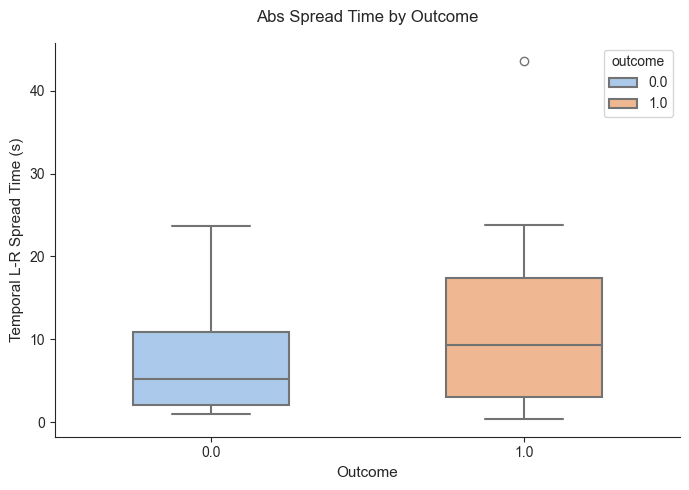

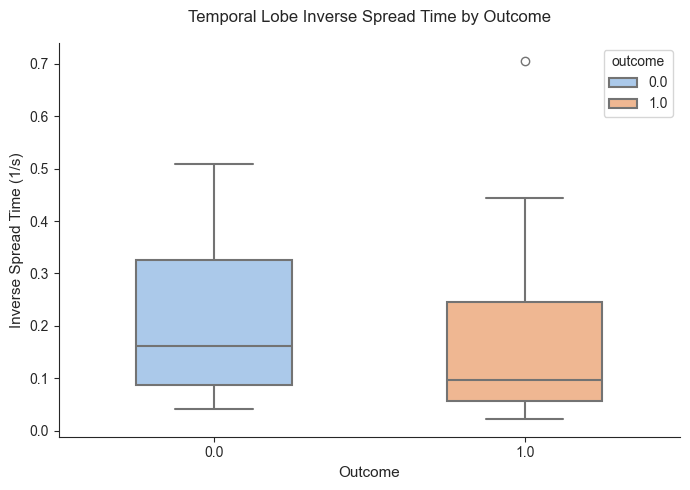

In [6]:
#seizure_spread_dynasd_bilteral = seizure_spread_dynasd[seizure_spread_dynasd['implant_laterality'] == 'bilateral']
seizure_spread_dynasd_bilteral = seizure_spread_dynasd[seizure_spread_dynasd['implant_temporal_laterality'] == 'bilateral_temporal']
#seizure_spread_dynasd_bilteral = seizure_spread_dynasd_bilteral.dropna(subset=['time']) # drop nans?

temporal_df = seizure_spread_dynasd_bilteral[
    seizure_spread_dynasd_bilteral['roi_lobe'].isin(['mesial_temporal', 'lateral_temporal'])
]

# avg time per laterality (left vs right temporal)
seizure_laterality_times = temporal_df.groupby(['patient', 'outcome', 'laterality', 'roi_laterality']).agg({
    'time': 'mean'  # avg activation time per side
}).reset_index()

seizure_times_wide = seizure_laterality_times.pivot(
    index=['patient', 'outcome', 'laterality'], 
    columns='roi_laterality', 
    values='time'
).reset_index()

# calc time difference (spread time)
seizure_times_wide['spread_time'] = abs(seizure_times_wide['left'] - seizure_times_wide['right'])

# Calculate inverse spread time (1/spread_time)
seizure_times_wide['spread_time'] = seizure_times_wide['spread_time'].fillna(np.inf)
seizure_times_wide['inverse_spread_time'] = 1 / ((seizure_times_wide['spread_time']) + 1)

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("ticks")
sns.set_palette("pastel")

# Plot 1: Spread time by outcome
plt.figure(figsize=(7, 5))
sns.boxplot(data=seizure_times_wide, x='outcome', y='spread_time', 
            palette='pastel', hue='outcome',  width=0.5, linewidth=1.5)
sns.despine()
plt.ylabel('Temporal L-R Spread Time (s)', fontsize=11)
plt.xlabel('Outcome', fontsize=11)
plt.title('Abs Spread Time by Outcome', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

# Plot 2: Inverse spread time by outcome
plt.figure(figsize=(7, 5))
sns.boxplot(data=seizure_times_wide, x='outcome', y='inverse_spread_time', 
            palette='pastel', hue='outcome', width=0.5, linewidth=1.5)
sns.despine()
plt.ylabel('Inverse Spread Time (1/s)', fontsize=11)
plt.xlabel('Outcome', fontsize=11)
plt.title('Temporal Lobe Inverse Spread Time by Outcome', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

thresholded by cutoffs (andy figures)

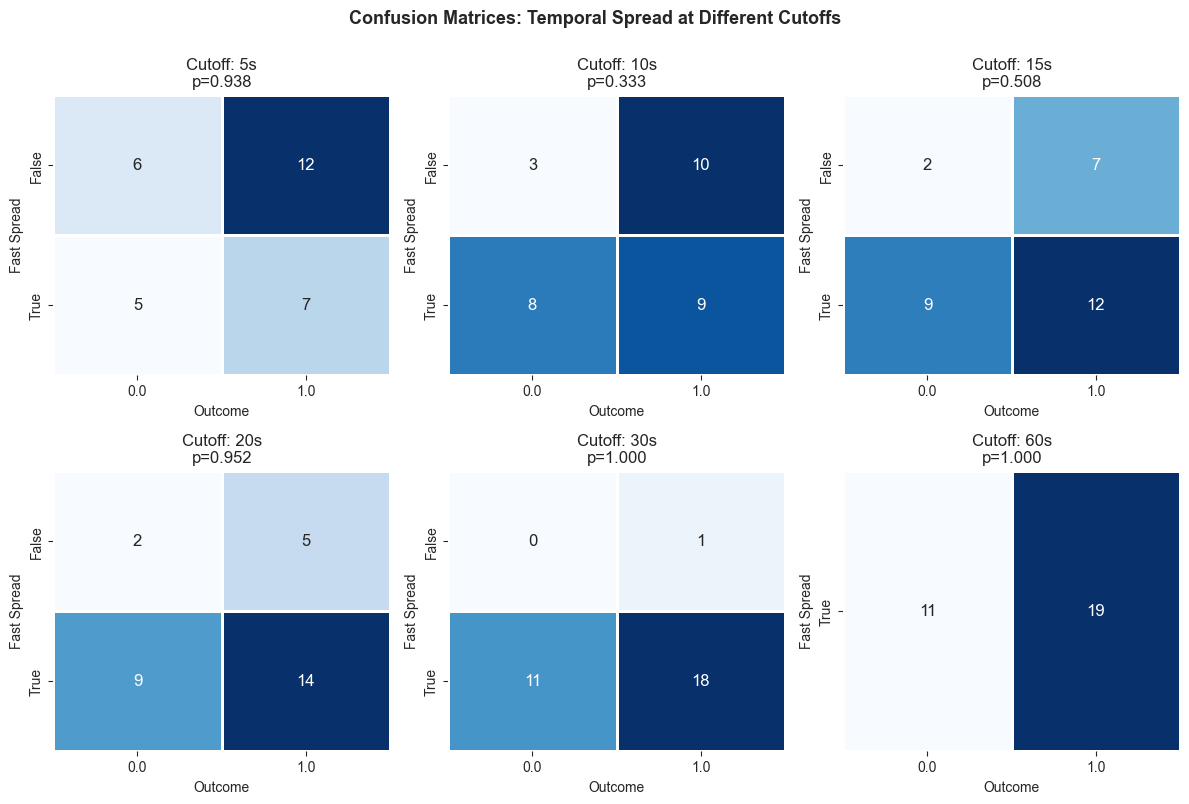

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
import numpy as np

# Create subplot grid for confusion matrices
fig, axes = plt.subplots(2, 3, figsize=(12, 8))
axes = axes.flatten()

cutoffs = [5, 10, 15, 20, 30, 60]

for idx, cutoff in enumerate(cutoffs):
    inv_cutoff = 1/cutoff
    
    # Does spread happen within cutoff time
    seizure_times_wide[f'spread_within_{cutoff}s'] = seizure_times_wide['inverse_spread_time'] > inv_cutoff
    
    # CM
    table = pd.crosstab(seizure_times_wide[f'spread_within_{cutoff}s'], 
                        seizure_times_wide['outcome'],
                        rownames=['Fast Spread'],
                        colnames=['Outcome'])
    
    # calc chi-square p-value
    chi2, p_val, dof, expected = chi2_contingency(table)
    
    # plot confusion matrix
    sns.heatmap(table, annot=True, fmt='d', cmap='Blues', 
                cbar=False, ax=axes[idx], linewidths=1, linecolor='white',
                annot_kws={'size': 12})
    
    # Add title with p-value
    sig = '*' if p_val < 0.05 else ''
    axes[idx].set_title(f'Cutoff: {cutoff}s\np={p_val:.3f}')
    axes[idx].set_xlabel('Outcome', fontsize=10)
    axes[idx].set_ylabel('Fast Spread', fontsize=10)

plt.suptitle('Confusion Matrices: Temporal Spread at Different Cutoffs', 
             fontsize=13, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

#### Time to Spread Analysis (Other)

temporally focused:
- temporal onset, bilateral spread
- temporal onset, spread to other temporal lobe
- temporal onset, spread outside temporal lobe
- mesial temporal onset, spread to lateral temporal (unilateral and bilateral)

all regions:
- bilteral spread
- spread outside the resection zone

##### First time of spread outside of the resection zone

This is min time, might want to do other versions

Seizures with both resected and non-resected data: 272

Spread time by outcome:
         count       mean        std  min  25%  50%  75%    max
outcome                                                        
0.0      119.0   2.235294   6.566422  0.0  0.0  0.0  1.5   50.5
1.0      126.0  11.341270  29.445315  0.0  0.0  0.0  7.0  197.0


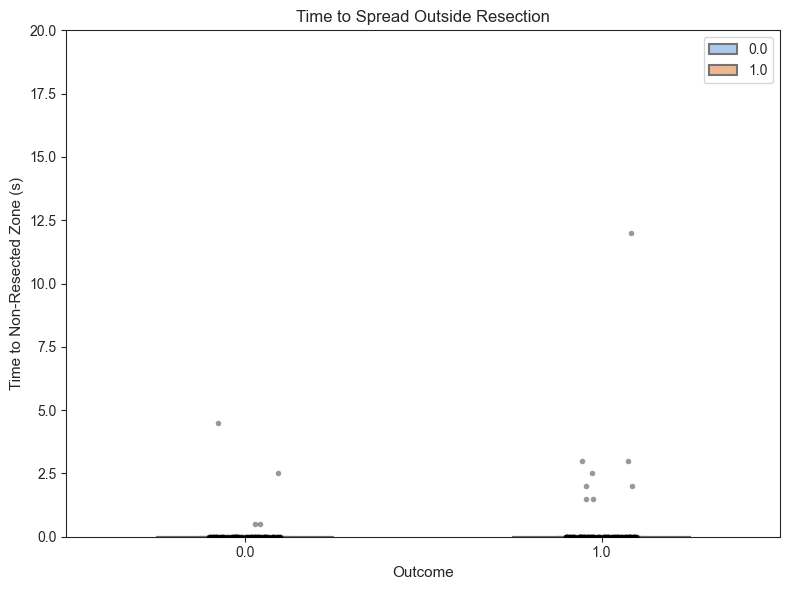

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# filter for seizures with resection data
resection_seizures = seizure_spread_dynasd[seizure_spread_dynasd['resected'].notna()].copy()

# get earliest time in resected zone for each seizure
resected_spread = resection_seizures[resection_seizures['resected'] == True].groupby(['onset', 'outcome']).agg({
    'time': 'min'
}).reset_index()
resected_spread.columns = ['onset', 'outcome', 'time_to_resected']

# get earliest time in non-resected zone for each seizure
non_resected_spread = resection_seizures[resection_seizures['resected'] == False].groupby(['onset', 'outcome']).agg({
    'time': 'min'
}).reset_index()
non_resected_spread.columns = ['onset', 'outcome', 'time_to_non_resected']

# merge both
spread_comparison = resected_spread.merge(non_resected_spread, on=['onset', 'outcome'], how='inner')

# calc absolute difference
spread_comparison['spread_time'] = abs(spread_comparison['time_to_non_resected'] - spread_comparison['time_to_resected'])

print(f"Seizures with both resected and non-resected data: {len(spread_comparison)}")
print(f"\nSpread time by outcome:")
print(spread_comparison.groupby('outcome')['spread_time'].describe())

# plot
sns.set_style("ticks")
fig, ax = plt.subplots(figsize=(8, 6))

#  time to non-resected zone
sns.boxplot(data=non_resected_spread, x='outcome', y='time_to_non_resected',
            ax=ax, palette='pastel', hue='outcome', width=0.5, linewidth=1.5, showfliers=False)
sns.stripplot(data=non_resected_spread, x='outcome', y='time_to_non_resected',
              ax=ax, color='black', alpha=0.4, size=4)
ax.set_ylabel('Time to Non-Resected Zone (s)', fontsize=11)
ax.set_xlabel('Outcome', fontsize=11)
ax.set_title('Time to Spread Outside Resection', fontsize=12)
ax.set_ylim(0, 20)

plt.tight_layout()
plt.show()

##### Other spread measures (bilteral, extra-temporal)

Make big dataframe with all information (for all patients/seizures, later can filter by what you want)

In [9]:
# make df with first time of spread (bilterally, extratemporally, ect.)

import numpy as np
results = []

onset = 0
threshold = None

# filter for bilateral implants only
#seizure_spread_dynasd_bilateral = seizure_spread_dynasd[seizure_spread_dynasd['implant_laterality'] == 'bilateral']
print(f"Total seizures with bilateral implants: {seizure_spread_dynasd['onset'].nunique()}")
print(f"Total patients with bilateral implants: {seizure_spread_dynasd['patient'].nunique()}")

# filter for not null times
seizure_spread_dynasd_filtered = seizure_spread_dynasd.dropna(subset=['time'])

# drop seizures without any spread (all time == nan)
seizure_spread_dynasd_filtered = seizure_spread_dynasd_filtered.groupby(['patient', 'onset']).filter(
    lambda x: x['time'].notna().any()
)

# Group by patient and seizure
for (patient_id, seizure_id), seizure_data in seizure_spread_dynasd_filtered.groupby(
    ['patient', 'onset']):
    
    seizure_data = seizure_data.sort_values('time').reset_index(drop=True)

    if threshold is not None:
        seizure_data = seizure_data[seizure_data['time'] <= threshold]

    # classify onset type based on whether temporal channels involved at onset (temporal, temporal plus, or non-temporal)
    onset_roi_lobes = seizure_data[seizure_data['time'] == 0]['roi_lobe'].unique()
    temporal_lobes = {'mesial_temporal', 'lateral_temporal'}
    onset_lobes_set = set(onset_roi_lobes)
    has_temporal = bool(onset_lobes_set & temporal_lobes)
    has_other = bool(onset_lobes_set - temporal_lobes)
    onset_type = 'temporal_plus' if has_temporal and has_other else ('temporal' if has_temporal else 'non-temporal')
    
    lateralities_over_time = seizure_data['roi_laterality'].values

    # find first occurrence of each hemisphere
    left_times = seizure_data[seizure_data['roi_laterality'] == 'left']['time']
    right_times = seizure_data[seizure_data['roi_laterality'] == 'right']['time']

    # check if both hemispheres are present
    if not left_times.empty and not right_times.empty:
        time_to_bilateral = max(left_times.min(), right_times.min())
    else:
        time_to_bilateral = None

    # for bilateral temporal spread specifically
    left_temporal = seizure_data[
        (seizure_data['roi_laterality'] == 'left') & 
        (seizure_data['roi_lobe'].isin(['mesial_temporal', 'lateral_temporal']))
    ]['time']

    right_temporal = seizure_data[
        (seizure_data['roi_laterality'] == 'right') & 
        (seizure_data['roi_lobe'].isin(['mesial_temporal', 'lateral_temporal']))
    ]['time']

    if not left_temporal.empty and not right_temporal.empty:
        time_to_bilateral_temporal = max(left_temporal.min(), right_temporal.min())
    else:
        time_to_bilateral_temporal = None

    # find time to extratemporal spread (either lobe)
    extratemporal = seizure_data[
        (~seizure_data['roi_lobe'].isin(['mesial_temporal', 'lateral_temporal'])) &
        (seizure_data['roi_lobe'] != 'white-matter')
    ]['time']

    if not extratemporal.empty:
        time_to_extratemporal = extratemporal.min()
    else:
        time_to_extratemporal = None

        resected_times = seizure_data[seizure_data['resected'] == True]['time']
    non_resected_times = seizure_data[seizure_data['resected'] == False]['time']

    results.append({
        'patient': patient_id,
        'seizure': seizure_id,
        'outcome': seizure_data['outcome'].iloc[0],
        'engel_group': seizure_data['engel_group'].iloc[0],
        'therapy': seizure_data['therapy'].iloc[0],
        'laterality': seizure_data['laterality'].iloc[0],
        'target': seizure_data['target'].iloc[0],
        'ATL': seizure_data['atl'].iloc[0],
        'onset_type': onset_type,
        'implant_laterality': seizure_data['implant_laterality'].iloc[0],
        'implant_temporal_laterality': seizure_data['implant_temporal_laterality'].iloc[0],
        'time_to_bilateral': time_to_bilateral,
        'time_to_bilateral_temporal': time_to_bilateral_temporal,
        'time_to_extratemporal': time_to_extratemporal,
        'lateralities_sequence': list(lateralities_over_time),
        'is_bilateral_spread': time_to_bilateral is not None,
        'is_bilateral_temporal_spread': time_to_bilateral_temporal is not None,
        'is_extratemporal_spread': time_to_extratemporal is not None,
    })

expanded_spread_df = pd.DataFrame(results)

Total seizures with bilateral implants: 700
Total patients with bilateral implants: 73


Has bilateral spread (bilteral implant):

Bilateral spread: chi2=14.58, p=0.0001


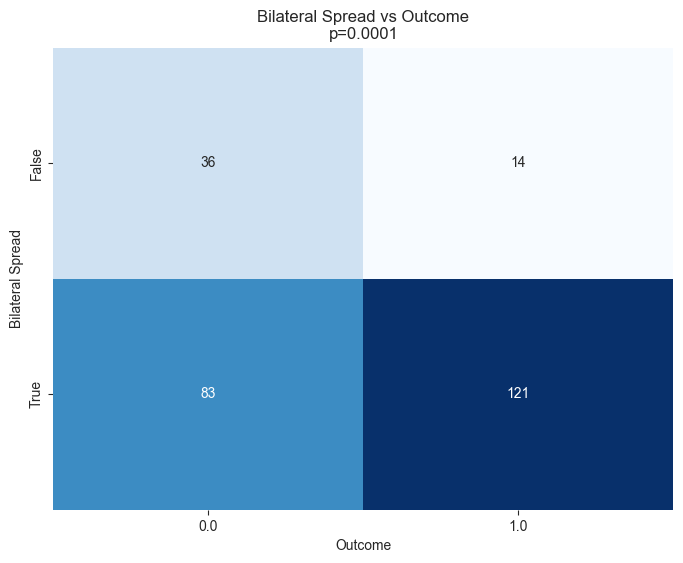

In [10]:
# Filter for bilateral implants
bilateral_df = expanded_spread_df[expanded_spread_df['implant_laterality'] == 'bilateral']
#bilateral_df = bilateral_df[bilateral_df['ATL'] == True]

# per patient, look at mode value or for any bilteral spread
# patient_summary = bilateral_df.groupby(['patient', 'outcome']).agg({
#     'is_bilateral_spread' : 'any'}).reset_index()

# patient_summary = bilateral_df.groupby(['patient', 'outcome', 'engel_group']).agg({
#     'is_bilateral_spread': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
# }).reset_index()

# confusion matrix
table1 = pd.crosstab(bilateral_df['is_bilateral_spread'], bilateral_df['outcome'])
chi2_1, p1, dof1, exp1 = chi2_contingency(table1)

print(f"Bilateral spread: chi2={chi2_1:.2f}, p={p1:.4f}")

plt.figure(figsize=(8, 6))
sns.heatmap(table1, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title(f'Bilateral Spread vs Outcome\np={p1:.4f}')
plt.xlabel('Outcome')
plt.ylabel('Bilateral Spread')
plt.show()

In [11]:
bilateral_df = expanded_spread_df[expanded_spread_df['implant_laterality'] == 'bilateral']
bilteral_temporalsurg_df = expanded_spread_df[expanded_spread_df['target'].isin(['MTL', 'Temporal'])]

In [12]:
bilteral_temporalsurg_df['onset_type'].unique()

array(['temporal_plus', 'temporal', 'non-temporal'], dtype=object)

Has bilteral bilteral spread, bilteral temporal spread, or extratemporal spread (filtered for bilteral temporal implants, and therapy targetting TL):

In [13]:
bilateral_temporal_df = expanded_spread_df[expanded_spread_df['implant_temporal_laterality'] == 'bilateral_temporal']
bilteral_temporalsurg_df = bilateral_temporal_df[bilateral_temporal_df['target'].isin(['MTL', 'Temporal'])]
bilteral_temporalsurg_test_df = bilteral_temporalsurg_df[bilteral_temporalsurg_df['onset_type'] != 'non-temporal']
#bilteral_atl_df = bilateral_temporal_df[bilateral_temporal_df['ATL'] == True]

# per patient, look at mode value or for any bilteral spread
# patient_summary = bilateral_df.groupby(['patient', 'outcome']).agg({
#     'is_bilateral_spread' : 'any',
#     'is_bilateral_temporal_spread': 'any',
#     'is_extratemporal_spread': 'any'

#     }).reset_index()

# patient_summary = bilateral_df.groupby(['patient', 'outcome', 'engel_group']).agg({
#     'is_bilateral_spread': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
#     'is_bilateral_temporal_spread': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0],
#     'is_extratemporal_spread': lambda x: x.mode()[0] if not x.mode().empty else x.iloc[0]
# }).reset_index()

# contingency tables
table1 = pd.crosstab(bilteral_temporalsurg_test_df['is_bilateral_spread'], bilteral_temporalsurg_test_df['outcome'])
chi2_1, p1, dof1, exp1 = chi2_contingency(table1)

table2 = pd.crosstab(bilteral_temporalsurg_test_df['is_bilateral_temporal_spread'], bilteral_temporalsurg_test_df['outcome'])
chi2_2, p2, dof2, exp2 = chi2_contingency(table2)

table3 = pd.crosstab(bilteral_temporalsurg_test_df['is_extratemporal_spread'], bilteral_temporalsurg_test_df['outcome'])
chi2_3, p3, dof3, exp3 = chi2_contingency(table3)

print(f"Bilateral spread: chi2={chi2_1:.2f}, p={p1:.4f}")
print(f"Bilateral temporal spread: chi2={chi2_2:.2f}, p={p2:.4f}")
print(f"Extratemporal spread: chi2={chi2_3:.2f}, p={p3:.4f}")

Bilateral spread: chi2=3.06, p=0.0804
Bilateral temporal spread: chi2=1.47, p=0.2257
Extratemporal spread: chi2=0.00, p=1.0000


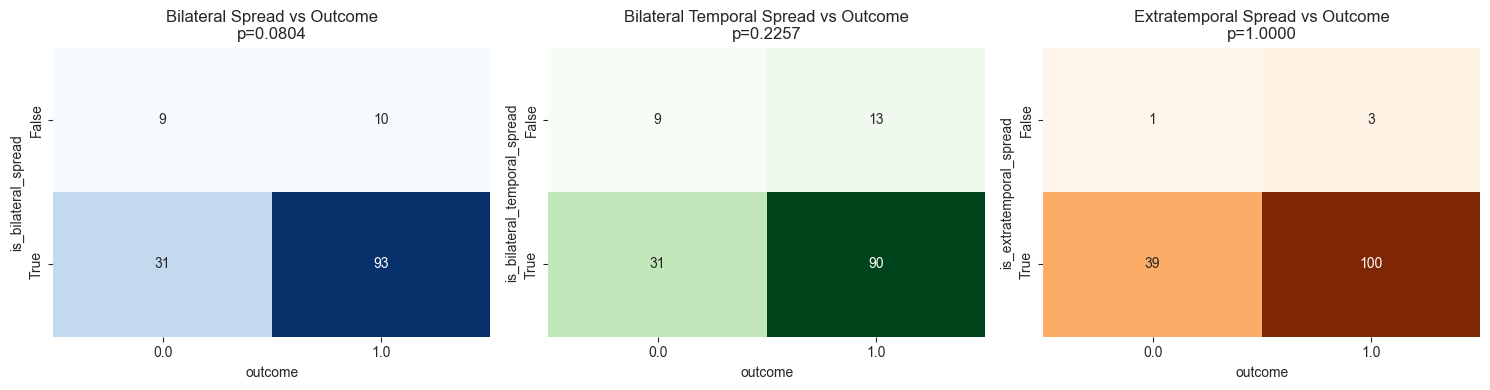

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create and visualize each table
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Bilateral spread
sns.heatmap(table1, annot=True, fmt='d', cmap='Blues', ax=axes[0], cbar=False)
axes[0].set_title(f'Bilateral Spread vs Outcome\np={p1:.4f}')

# Bilateral temporal spread
sns.heatmap(table2, annot=True, fmt='d', cmap='Greens', ax=axes[1], cbar=False)
axes[1].set_title(f'Bilateral Temporal Spread vs Outcome\np={p2:.4f}')

# Extratemporal spread
sns.heatmap(table3, annot=True, fmt='d', cmap='Oranges', ax=axes[2], cbar=False)
axes[2].set_title(f'Extratemporal Spread vs Outcome\np={p3:.4f}')

plt.tight_layout()
plt.show()

Plots of the the first time to bilteral implant

<Axes: xlabel='outcome', ylabel='time_to_bilateral_temporal'>

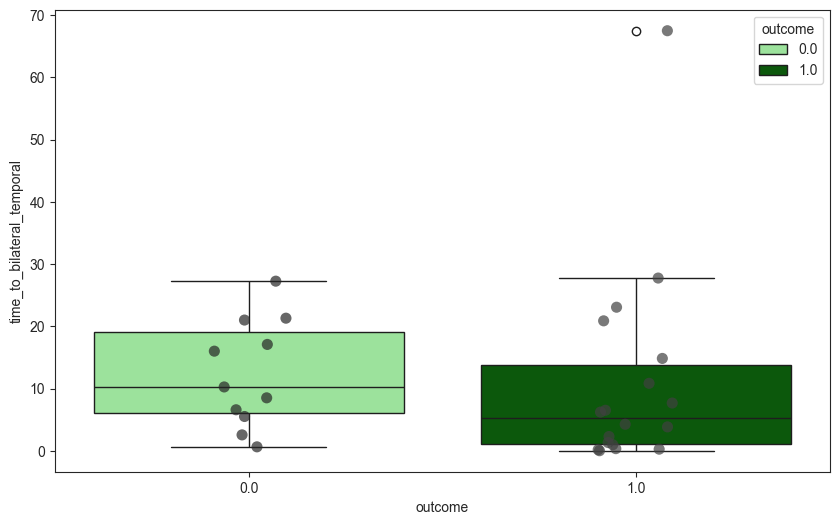

In [15]:
# group by patient
pt_bilateral_temporal_df = bilateral_temporal_df.groupby(['patient', 'outcome']).agg({
    'time_to_bilateral_temporal': 'mean',
    'is_bilateral_spread': 'sum'}).reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(x='outcome', y='time_to_bilateral_temporal', data=pt_bilateral_temporal_df, hue='outcome', palette=['lightgreen', 'darkgreen'])
sns.stripplot(x='outcome', y='time_to_bilateral_temporal', data=pt_bilateral_temporal_df, hue='outcome', palette='dark:0.25', jitter=True, size=8, alpha=0.7, legend=False)

<Axes: xlabel='outcome', ylabel='time_to_extratemporal'>

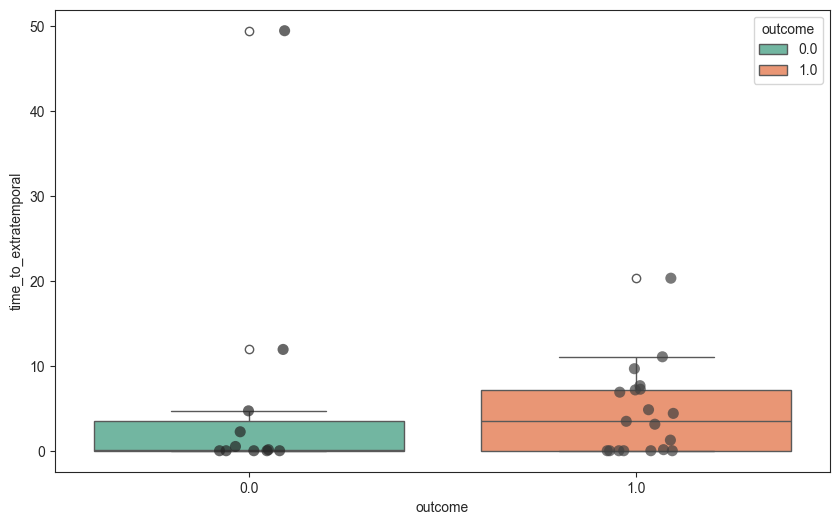

In [16]:
# plot boxplot of time to extratemporal spread by outcome (with labels for N patients)

# group by patient
pt_bilateral_temporal_spread_df = bilateral_temporal_df.groupby(['patient', 'outcome']).agg({
    'time_to_extratemporal': 'mean'}).reset_index()

plt.figure(figsize=(10, 6))
sns.boxplot(x='outcome', y='time_to_extratemporal', data=pt_bilateral_temporal_spread_df, hue='outcome', palette='Set2')
sns.stripplot(x='outcome', y='time_to_extratemporal', data=pt_bilateral_temporal_spread_df, hue='outcome', palette='dark:0.25', jitter=True, size=8, alpha=0.7, legend=False)

#### Focality of Spread Analysis

- Standard distance of seizing electrodes (from onset, across time)
    - Standard distance of seizing wm electrodes
    - Standard distance of seizing gm electrodes
- max(75% etc.) distance of recruited channels from SOZ centroid (3 seconds)
- max distance of recruited white matter channels over time
- max distance of recruited gray matter channels over time

##### Percent Recruited

Text(0.5, 1.0, 'Seizure spread over time')

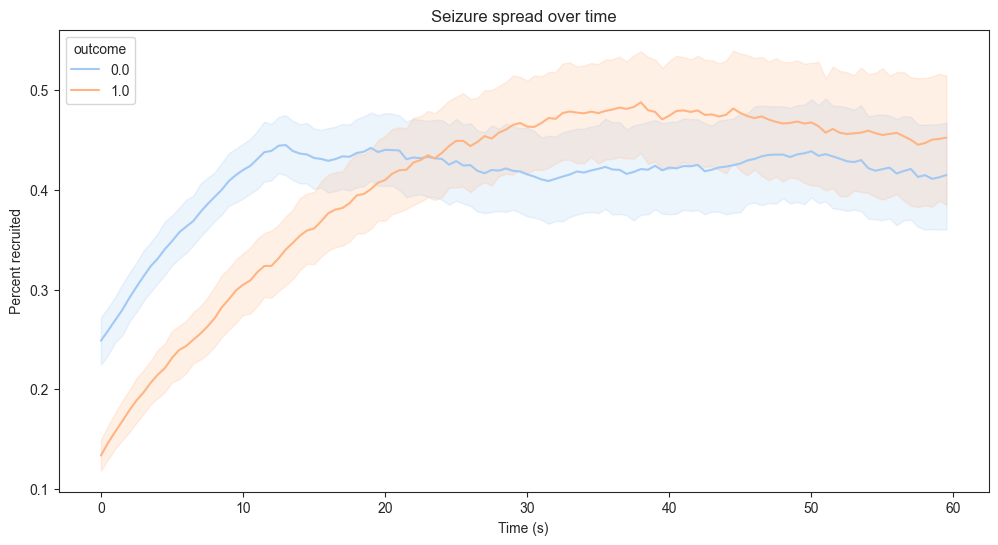

In [17]:
seizure_spread_dynasd['num_channels'] = seizure_spread_dynasd.groupby('onset')['channel'].transform('count')

onset_threshold = 0
time_grid = np.arange(0, 60, 0.5)

# list to collect all distance data
seizing_data = []

# filter only not null times
seizure_spread_dynasd_recruited = seizure_spread_dynasd.dropna(subset=['time'])

# group by patient and seizure
for (patient_id, seizure_id), seizure_data in seizure_spread_dynasd_recruited.groupby(
    ['patient', 'onset']):

    valid_channels = seizure_data.dropna(subset=['mm_x', 'mm_y', 'mm_z'])

    max_time = valid_channels['time'].max()
    relevant_time_grid = time_grid[time_grid <= max_time]

    for time_point in relevant_time_grid:
        
        channels_up_to_now = valid_channels[valid_channels['time'] <= time_point]    
        percent_seizing = len(channels_up_to_now)/seizure_data['num_channels'].iloc[0]
            
        seizing_data.append({
            'patient_id': patient_id,
            'seizure_id': seizure_id,
            'outcome': seizure_data['outcome'].iloc[0],
            'time': time_point,
            'percent_seizing' : percent_seizing
        })

percent_seizing_df = pd.DataFrame(seizing_data)

# plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=percent_seizing_df, x='time', hue='outcome', y='percent_seizing')
plt.xlabel('Time (s)')
plt.ylabel('Percent recruited')
plt.title('Seizure spread over time')

Text(0.5, 1.0, 'Seizure spread over time')

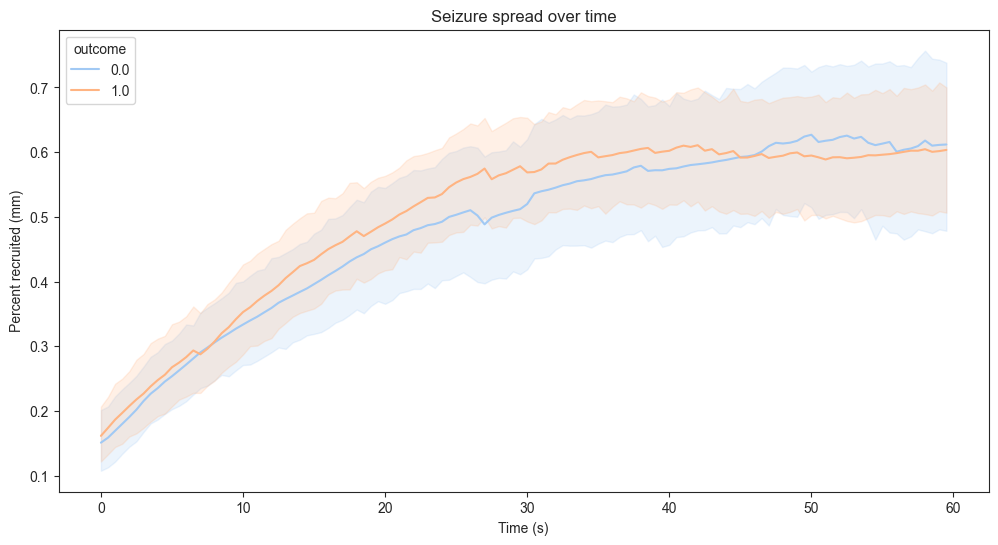

In [18]:
# group by patient and outcome to get mean distance over time
pt_seizing_df = percent_seizing_df.groupby(['patient_id', 'outcome', 'time']).agg({
    'percent_seizing': 'mean'}).reset_index()

# plot
plt.figure(figsize=(12, 6))
sns.lineplot(data=pt_seizing_df, x='time', hue='outcome', y='percent_seizing')
plt.xlabel('Time (s)')
plt.ylabel('Percent recruited (mm)')
plt.title('Seizure spread over time')

##### Focality Measures

Make a big df with all of the focality measures per patient and seizure:

In [19]:
# make big df with all focality measures

time_grid = np.arange(0, 60, 0.5)

centroid_choice = 'resection_mask'
onset_threshold = 0

distance_data = []

# filter only not null times
seizure_spread_dynasd_filtered = seizure_spread_dynasd.dropna(subset=['time'])

#filter for patients with resection information
seizure_spread_dynasd_filtered = seizure_spread_dynasd.dropna(subset=['resected'])

# group by patient and seizure
for (patient_id, seizure_id), seizure_data in seizure_spread_dynasd_filtered.groupby(
    ['patient', 'onset']):

    # patient response status
    outcome = seizure_data['outcome'].iloc[0]
    
    valid_channels = seizure_data.dropna(subset=['mm_x', 'mm_y', 'mm_z'])
    valid_wm_channels = seizure_data[seizure_data['roi_type'] == 'WM']
    valid_gm_channels = seizure_data[seizure_data['roi_type'] == 'GM']

    channel_sets = {'all' :valid_channels,
                    'WM' :valid_wm_channels,
                    'GM': valid_gm_channels}

    for set_name, channel_set in channel_sets.items():
        
        total_channels = len(channel_set)

        if total_channels == 0:
            print(f"Warning: No valid coordinates for {patient_id} seizure {seizure_id} in {set_name}")
            continue
        
        try:
            if centroid_choice == 'resection_mask':
                early_onset = channel_set[channel_set['resected'] == True]
            elif centroid_choice == 'onset':
                early_onset = channel_set[channel_set['time'] <= onset_threshold]
            else:
                raise ValueError(f"Invalid centroid_choice: '{centroid_choice}'")
        except NameError:
            raise ValueError('centroid_choice is not defined')

        if len(early_onset) == 0:
            print(f"Warning: No early onset channels for {patient_id} seizure {seizure_id} in {set_name}")
            continue

        # get centroid of early onset channels
        coords = early_onset[['mm_x', 'mm_y', 'mm_z']].astype(float).values
        centroid = np.mean(coords, axis=0)

        # Loop through time grid
        for time_point in time_grid:
            
            # Get channels recruited up to this timepoint
            channels_up_to_now = channel_set[channel_set['time'] <= time_point]
            
            if len(channels_up_to_now) == 0:
                std_distance = np.nan
                mean_distance = np.nan
                max_distance = np.nan
                percentile_distance = np.nan
            else:
                # get distances of all recruited channels
                coords_now = channels_up_to_now[['mm_x', 'mm_y', 'mm_z']].astype(float).values
                distances = np.sqrt(np.sum((coords_now - centroid)**2, axis=1))
                
                # calculate features
                std_distance = np.std(distances)
                mean_distance = np.mean(distances)
                max_distance = np.max(distances)
                percentile_distance = np.percentile(distances, 75)

            # append one row per time_point per set_name
            distance_data.append({
                'patient_id': patient_id,
                'seizure_id': seizure_id,
                'outcome': outcome,
                'channel_set': set_name,
                'time': time_point,
                'std_distance': std_distance,
                'mean_distance': mean_distance,
                'max_distance': max_distance,
                '75th_percentile_distance' : percentile_distance
            })

            # if no times more than time_point, break
            if time_point >= channel_set['time'].max():
                break

# Convert to dataframe
distance_df = pd.DataFrame(distance_data)

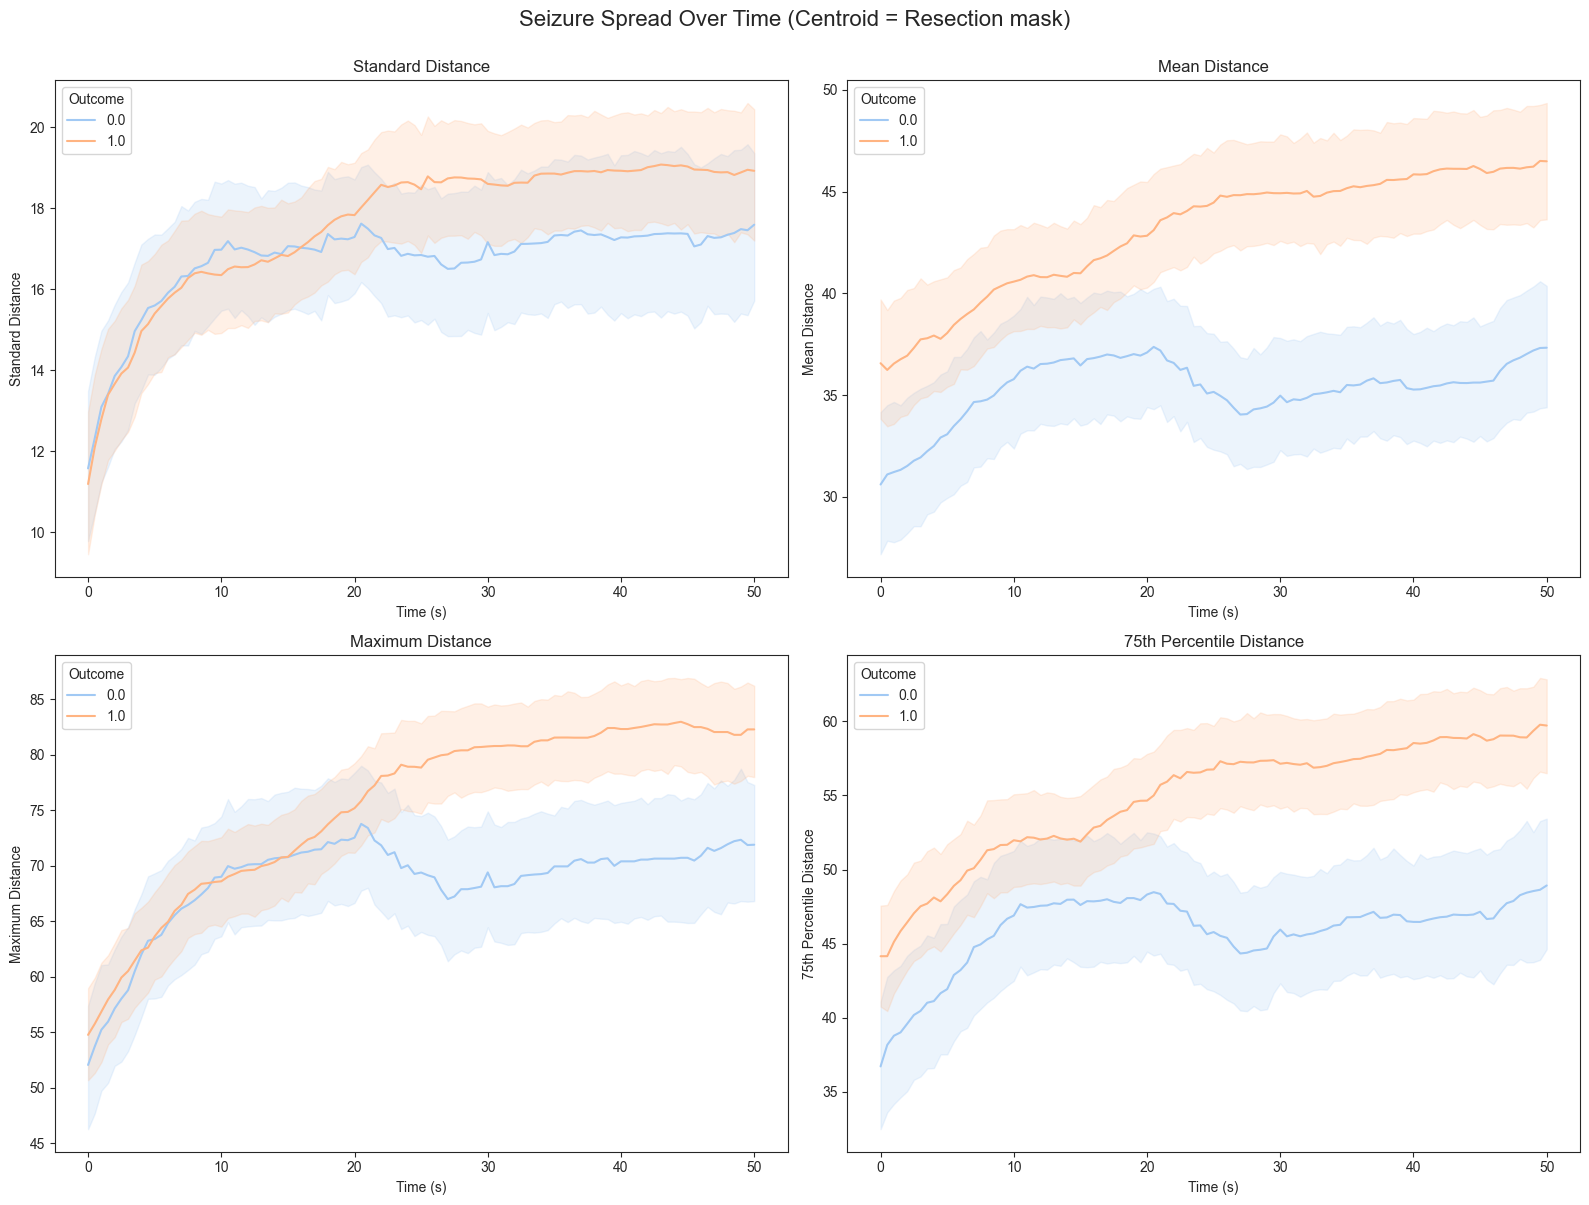

In [20]:
# filter first
distance_df_50s = distance_df[distance_df['time'] <= 50]
distance_df_50s_allchans = distance_df_50s[distance_df_50s['channel_set'] == 'all'] # set to all channels

# plot for each metric
metrics = ['std_distance', 'mean_distance', 'max_distance', '75th_percentile_distance']
metric_labels = {
    'std_distance': 'Standard Distance',
    'mean_distance': 'Mean Distance',
    'max_distance': 'Maximum Distance',
    '75th_percentile_distance': '75th Percentile Distance'
}
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for idx, metric in enumerate(metrics):
    sns.lineplot(data=distance_df_50s_allchans, x='time', hue='outcome', 
                 y=metric, ax=axes[idx])
    axes[idx].set_xlabel('Time (s)')
    axes[idx].set_ylabel(metric_labels[metric])
    axes[idx].set_title(f'{metric_labels[metric]}')
    axes[idx].legend(title='Outcome')

plt.suptitle('Seizure Spread Over Time (Centroid = Resection mask)', fontsize=16, y=1.00)
plt.tight_layout()
plt.show()

In [21]:
# stats test
from scipy.stats import mannwhitneyu

seconds_threshold = 10
stats_test_df = distance_df_50s_allchans[distance_df_50s_allchans['time'] == seconds_threshold]

good_outcome_dist = stats_test_df[
    stats_test_df['outcome'] == 1]['std_distance'].dropna()

poor_outcome_dist = stats_test_df[
    stats_test_df['outcome'] == 0]['std_distance'].dropna()

stat, p_value = mannwhitneyu(good_outcome_dist, poor_outcome_dist, alternative='two-sided')
print(f"Mann-Whitney U test between outcomes:")
print(f"U statistic: {stat}, p-value: {p_value:.4f}")

Mann-Whitney U test between outcomes:
U statistic: 7583.0, p-value: 0.5726


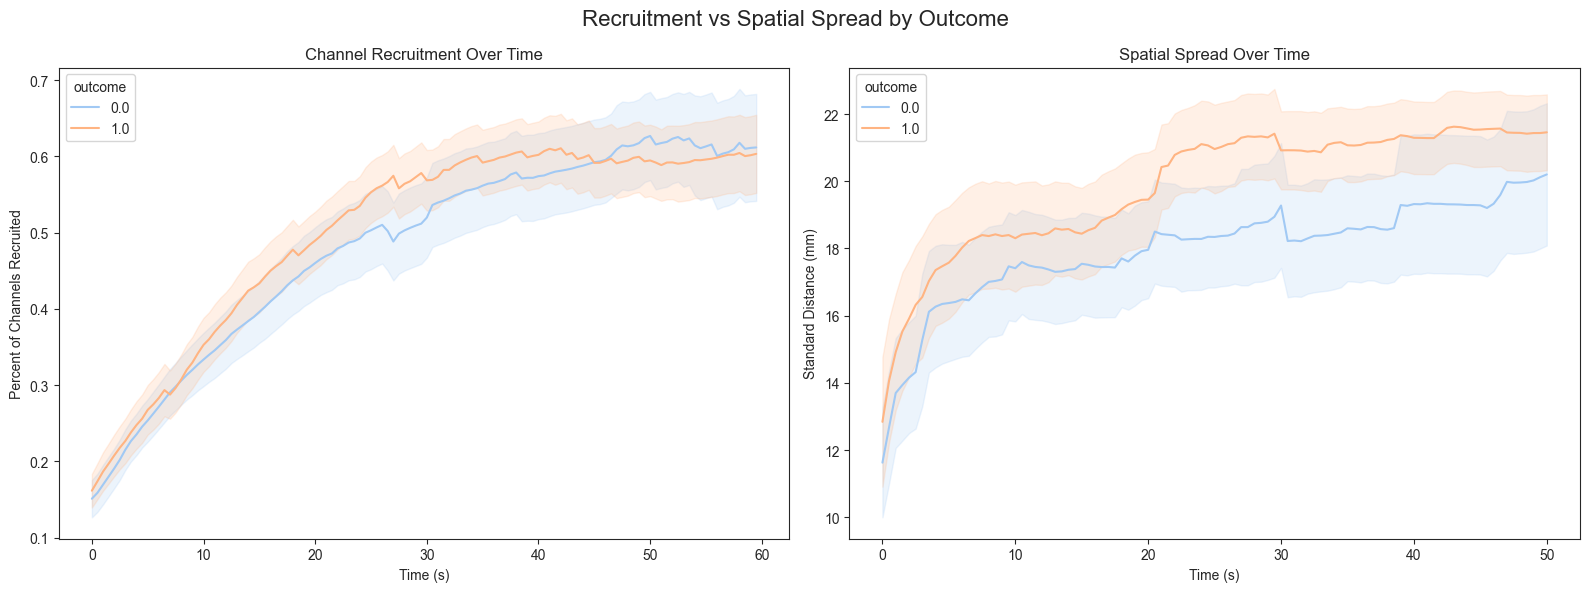

In [22]:
# avg by patient for percent seizing
percent_seizing_by_patient = percent_seizing_df.groupby(['patient_id', 'outcome', 'time'])['percent_seizing'].mean().reset_index()
distance_by_patient = distance_df_50s_allchans.groupby(['patient_id', 'outcome', 'time'])['std_distance'].mean().reset_index()

# Create side-by-side comparison
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Left: Percent recruited
sns.lineplot(data=percent_seizing_by_patient, x='time', y='percent_seizing', 
             hue='outcome', ax=axes[0], errorbar='se')
axes[0].set_xlabel('Time (s)')
axes[0].set_ylabel('Percent of Channels Recruited')
axes[0].set_title('Channel Recruitment Over Time')

# Right: Spatial spread
sns.lineplot(data=distance_by_patient, x='time', y='std_distance', 
             hue='outcome', ax=axes[1], errorbar='se')
axes[1].set_xlabel('Time (s)')
axes[1].set_ylabel('Standard Distance (mm)')
axes[1].set_title('Spatial Spread Over Time')

plt.suptitle('Recruitment vs Spatial Spread by Outcome', fontsize=16)
plt.tight_layout()
plt.show()

Look at focality of implant - i.e. all electrodes (using first seizure)

In [23]:
import numpy as np
import pandas as pd
from scipy.spatial.distance import pdist

spread_data = []

# use all channels with coordinates (no dropping na times)
seizure_spread_all = seizure_spread_dynasd.dropna(subset=['mm_x', 'mm_y', 'mm_z'])

# group by patient and take first seizure only
for patient_id, patient_data in seizure_spread_all.groupby('patient'):
    
    # Take just the first seizure for this patient
    first_seizure = patient_data['onset'].iloc[0]
    seizure_data = patient_data[patient_data['onset'] == first_seizure]
    
    outcome = seizure_data['outcome'].iloc[0]
    
    # Define channel sets
    valid_channels = seizure_data.dropna(subset=['mm_x', 'mm_y', 'mm_z'])
    valid_wm_channels = seizure_data[seizure_data['roi_type'] == 'WM']
    valid_gm_channels = seizure_data[seizure_data['roi_type'] == 'GM']

    channel_sets = {
        'all': valid_channels,
        'WM': valid_wm_channels,
        'GM': valid_gm_channels
    }

    for set_name, channel_set in channel_sets.items():
        
        total_channels = len(channel_set)

        if total_channels == 0:
            continue
        
        coords = channel_set[['mm_x', 'mm_y', 'mm_z']].astype(float).values
        centroid = np.mean(coords, axis=0)
        distances = np.sqrt(np.sum((coords - centroid)**2, axis=1))
        
        std_distance = np.std(distances)
        mean_distance = np.mean(distances)
        max_distance = np.max(distances)
        percentile_75_distance = np.percentile(distances, 75)
        percentile_25_distance = np.percentile(distances, 25)
        median_distance = np.median(distances)
        
        if total_channels > 1:
            pairwise_distances = pdist(coords)
            mean_pairwise_distance = np.mean(pairwise_distances)
            max_pairwise_distance = np.max(pairwise_distances)
        else:
            mean_pairwise_distance = 0
            max_pairwise_distance = 0
        
        spread_data.append({
            'patient_id': patient_id,
            'outcome': outcome,
            'channel_set': set_name,
            'num_channels': total_channels,
            'std_distance': std_distance,
            'mean_distance': mean_distance,
            'median_distance': median_distance,
            'max_distance': max_distance,
            '25th_percentile_distance': percentile_25_distance,
            '75th_percentile_distance': percentile_75_distance,
            'mean_pairwise_distance': mean_pairwise_distance,
            'max_pairwise_distance': max_pairwise_distance
        })

implant_distance_df = pd.DataFrame(spread_data)

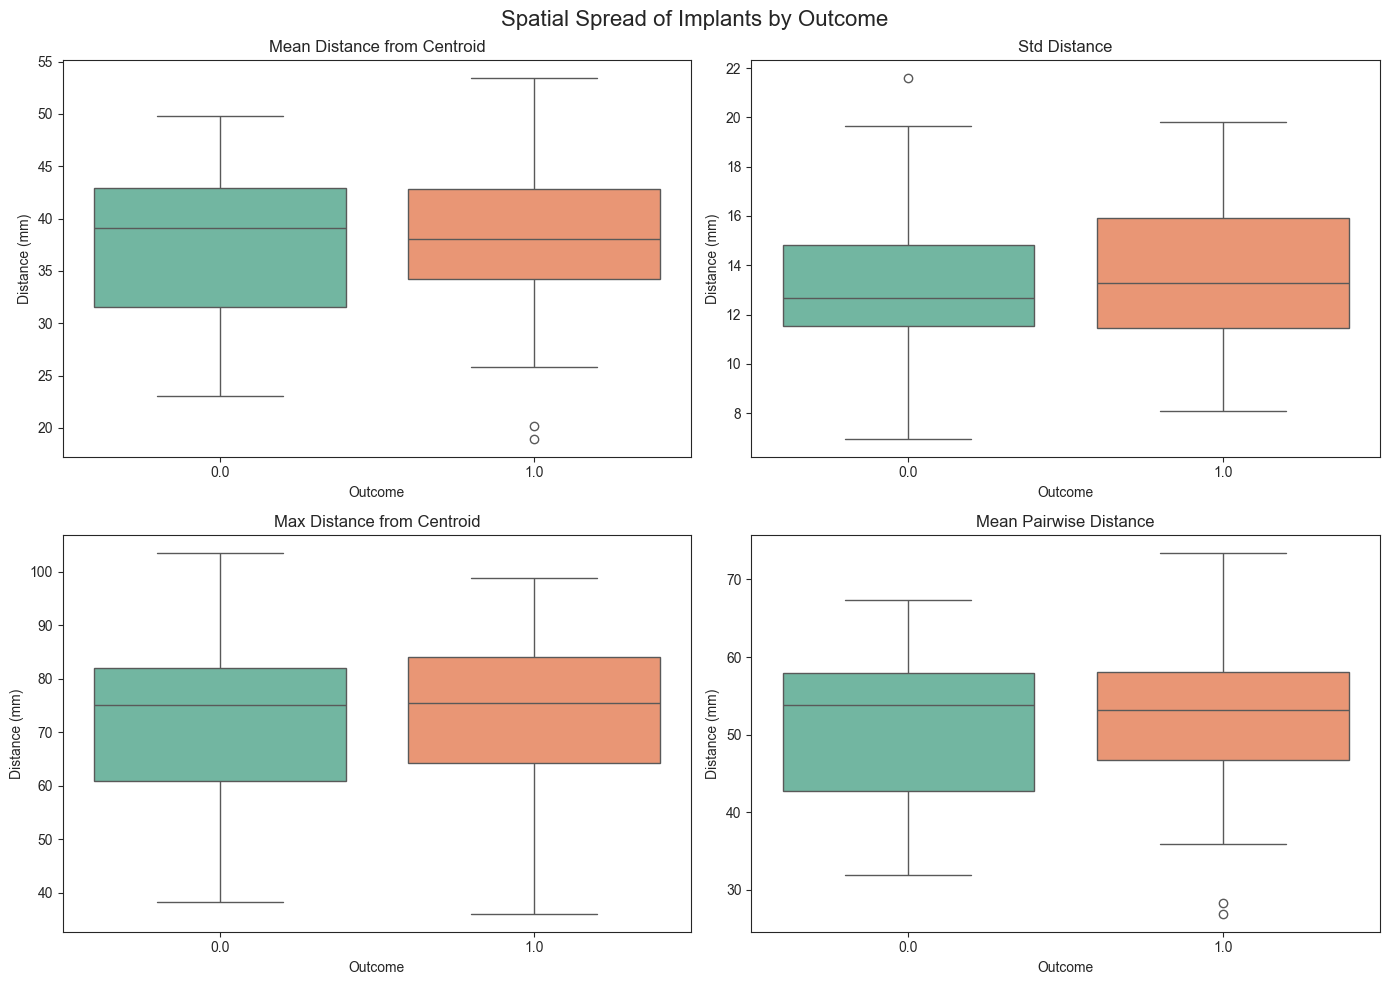

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

# filter for 'all' channels
implant_distance_all_df = implant_distance_df[implant_distance_df['channel_set'] == 'all']

# Create comparison plots
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

metrics = ['mean_distance', 'std_distance', 'max_distance', 'mean_pairwise_distance']
titles = ['Mean Distance from Centroid', 'Std Distance', 
          'Max Distance from Centroid', 'Mean Pairwise Distance']

for idx, (metric, title) in enumerate(zip(metrics, titles)):
    ax = axes.flat[idx]  # Get the correct subplot
    sns.boxplot(data=implant_distance_all_df, x='outcome', y=metric, 
                ax=ax, hue='outcome', palette='Set2', legend=False)
    ax.set_xlabel('Outcome')
    ax.set_ylabel('Distance (mm)')
    ax.set_title(title)

plt.suptitle('Spatial Spread of Implants by Outcome', fontsize=16)
plt.tight_layout()
plt.show()

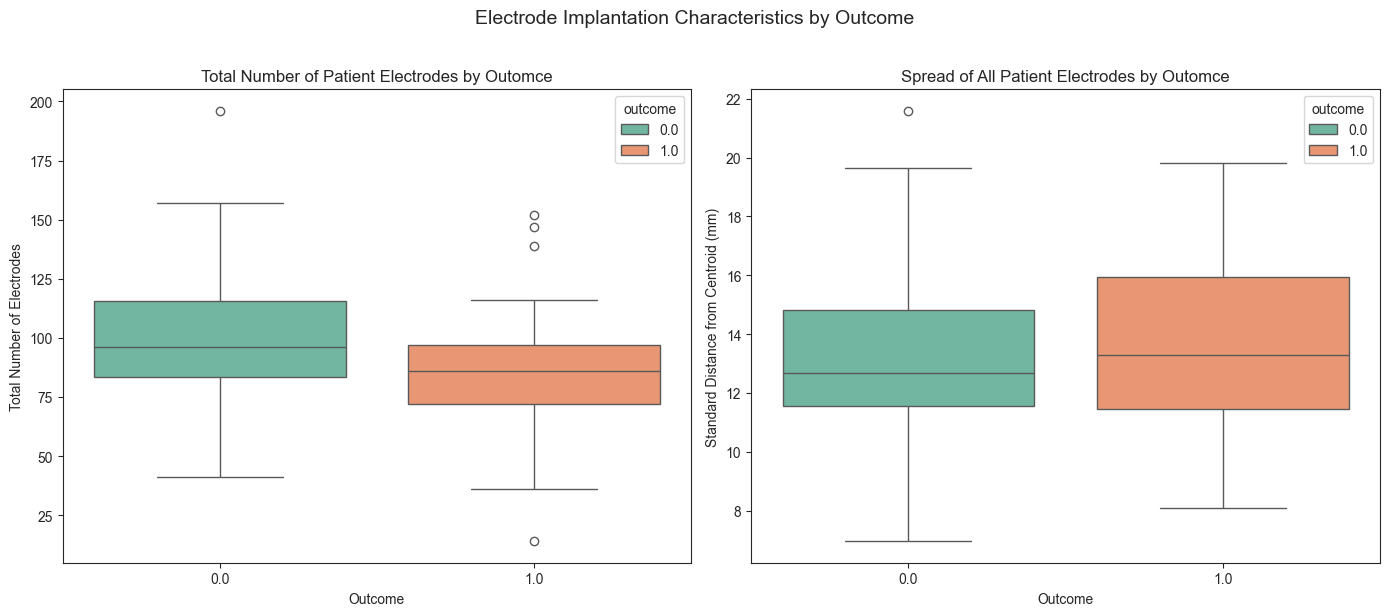

Total Electrodes per Patient (p=0.043)
Spatial Spread of Electrode Array (p=0.500)


In [25]:
#  create the figure with counts
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

#Total electrodes per patient
sns.boxplot(data=implant_distance_all_df, x='outcome', y='num_channels', hue='outcome', ax=axes[0], palette='Set2')
axes[0].set_ylabel('Total Number of Electrodes')
axes[0].set_xlabel('Outcome')
axes[0].set_title('Total Number of Patient Electrodes by Outomce')


# spatial spread
patient_spatial_stats = implant_distance_all_df[implant_distance_all_df['channel_set'] == 'all'][['patient_id', 'outcome', 'std_distance']]

sns.boxplot(data=patient_spatial_stats, x='outcome', y='std_distance', ax=axes[1], hue='outcome', palette='Set2')
axes[1].set_ylabel('Standard Distance from Centroid (mm)')
axes[1].set_xlabel('Outcome')
axes[1].set_title('Spread of All Patient Electrodes by Outomce')


plt.suptitle('Electrode Implantation Characteristics by Outcome', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Add stats
outcome_0 = implant_distance_all_df[implant_distance_all_df['outcome'] == 0]['num_channels']
outcome_1 = implant_distance_all_df[implant_distance_all_df['outcome'] == 1]['num_channels']
stat, pval = stats.mannwhitneyu(outcome_0, outcome_1)
print(f'Total Electrodes per Patient (p={pval:.3f})')

outcome_0_std = patient_spatial_stats[patient_spatial_stats['outcome'] == 0]['std_distance']
outcome_1_std = patient_spatial_stats[patient_spatial_stats['outcome'] == 1]['std_distance']
stat, pval = stats.mannwhitneyu(outcome_0_std, outcome_1_std)
print(f'Spatial Spread of Electrode Array (p={pval:.3f})')